# 07 - DiD Model and Sample Design

This notebook organizes the next stage of the project around two complementary samples:

- **Model 1**: a nationwide border-county main sample used for the headline estimate.
- **Model 2**: a smaller illustrative border sample used for intuition, visuals, and later event-study work.


## 1. Research Question

**Main question:** Does raising the minimum wage reduce employment in low-wage border counties, especially in food services?

We keep `NAICS 722` as the anchor industry because:
- it is the closest match to the classic border-county minimum wage literature,
- it is highly exposed to minimum wage policy,
- and it gives us the clearest first headline result before extending to other sectors.

We also track `log_wage` alongside `log_emp` because wage pass-through is an important first-stage validation.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", None)

CWD = Path().resolve()
ROOT = CWD if (CWD / "data" / "intermediate").exists() else CWD.parent
INTERMEDIATE = ROOT / "data" / "intermediate"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

PANEL_FILE = PROCESSED / "analysis_panel.parquet"
PAIRS_FILE = INTERMEDIATE / "border_pairs.parquet"

PRIMARY_INDUSTRY = "722"
INDUSTRIES = ["722", "44-45", "72", "721"]
SELECTED_BORDERS = ["NJ - PA", "MN - WI", "NY - PA", "CA - NV"]

## 2. Main Sample and Illustrative Sample

### Model 1: nationwide main sample
This is our preferred sample for the main estimate.
It uses **all eligible border-county pairs nationwide** that appear in the final analysis panel.

### Model 2: illustrative border sample
For visuals and later event-study work, we use four state borders:
- `NJ - PA`
- `MN - WI`
- `NY - PA`
- `CA - NV`

We choose these borders because they combine:
- clear and persistent minimum wage divergence,
- enough county-pair coverage,
- strong data completeness in `NAICS 722`,
- and a close fit with the project's border-county story.

The two models are **complements**, not competing main models:
- **Model 1** estimates the average effect across the nationwide border-county sample.
- **Model 2** gives us a smaller, more intuitive set of border comparisons for plots and extension work.


In [2]:
panel = pd.read_parquet(PANEL_FILE).copy()
pairs = pd.read_parquet(PAIRS_FILE).copy()

panel["industry_code"] = panel["industry_code"].astype(str)
panel["pair_id"] = panel["pair_id"].astype(int)
panel["year"] = panel["year"].astype(int)
panel["pair_year"] = panel["pair_id"].astype(str) + "_" + panel["year"].astype(str)
panel["mw_gap"] = panel["min_wage"] - panel["partner_min_wage"]
panel["mw_gap_abs"] = panel["mw_gap"].abs()
panel["complete_pair_year"] = (
    panel.groupby(["pair_id", "year", "industry_code"])["area_fips"].transform(
        "nunique"
    )
    == 2
)

pairs["border"] = pairs.apply(
    lambda row: " - ".join(sorted([str(row["state1"]), str(row["state2"])])), axis=1
)
panel = panel.merge(pairs[["pair_id", "border"]], on="pair_id", how="left")

main_sample = panel.copy()
main_722 = main_sample.loc[main_sample["industry_code"] == PRIMARY_INDUSTRY].copy()
illustrative_sample = main_sample.loc[
    main_sample["border"].isin(SELECTED_BORDERS)
].copy()
illustrative_722 = illustrative_sample.loc[
    illustrative_sample["industry_code"] == PRIMARY_INDUSTRY
].copy()

sample_summary = pd.DataFrame(
    {
        "rows": [
            len(main_sample),
            len(main_722),
            len(illustrative_sample),
            len(illustrative_722),
        ],
        "pair_ids": [
            main_sample["pair_id"].nunique(),
            main_722["pair_id"].nunique(),
            illustrative_sample["pair_id"].nunique(),
            illustrative_722["pair_id"].nunique(),
        ],
        "counties": [
            main_sample["area_fips"].nunique(),
            main_722["area_fips"].nunique(),
            illustrative_sample["area_fips"].nunique(),
            illustrative_722["area_fips"].nunique(),
        ],
        "borders": [
            main_sample["border"].nunique(),
            main_722["border"].nunique(),
            illustrative_sample["border"].nunique(),
            illustrative_722["border"].nunique(),
        ],
        "years": [
            main_sample["year"].nunique(),
            main_722["year"].nunique(),
            illustrative_sample["year"].nunique(),
            illustrative_722["year"].nunique(),
        ],
        "mean_abs_gap": [
            main_sample["mw_gap_abs"].mean(),
            main_722["mw_gap_abs"].mean(),
            illustrative_sample["mw_gap_abs"].mean(),
            illustrative_722["mw_gap_abs"].mean(),
        ],
    },
    index=["M1 all industries", "M1 NAICS 722", "M2 all industries", "M2 NAICS 722"],
)

sample_summary.round(3)

,rows,pair_ids,counties,borders,years,mean_abs_gap
M1 all industries,156971,1132,1026,103,21,1.258
M1 NAICS 722,39748,1131,1006,103,21,1.256
M2 all industries,11203,70,73,4,21,1.931
M2 NAICS 722,2790,70,73,4,21,1.936


In [3]:
selected_border_summary = (
    illustrative_722.groupby("border")
    .agg(
        county_pairs=("pair_id", "nunique"),
        counties=("area_fips", "nunique"),
        rows=("pair_id", "size"),
        mean_gap=("mw_gap_abs", "mean"),
        max_gap=("mw_gap_abs", "max"),
    )
    .reset_index()
)

selected_pair_year = illustrative_722.groupby(
    ["border", "pair_id", "year"], as_index=False
).agg(
    n_counties=("area_fips", "nunique"),
    min_mw=("min_wage", "min"),
    max_mw=("min_wage", "max"),
)
selected_pair_year["positive_gap"] = (
    selected_pair_year["max_mw"] - selected_pair_year["min_mw"]
) > 0

selected_pair_year_summary = (
    selected_pair_year.groupby("border")
    .agg(
        pair_years=("year", "size"),
        gap_pair_years=("positive_gap", "sum"),
        complete_pair_years=("n_counties", lambda s: (s == 2).sum()),
    )
    .reset_index()
)
selected_pair_year_summary["gap_share"] = (
    selected_pair_year_summary["gap_pair_years"]
    / selected_pair_year_summary["pair_years"]
)
selected_pair_year_summary["complete_share"] = (
    selected_pair_year_summary["complete_pair_years"]
    / selected_pair_year_summary["pair_years"]
)

selected_border_table = selected_border_summary.merge(
    selected_pair_year_summary, on="border"
)
selected_border_table.round(3)

,border,county_pairs,counties,rows,mean_gap,max_gap,pair_years,gap_pair_years,complete_pair_years,gap_share,complete_share
0,CA - NV,17,18,651,2.070,6.00,357,294,294,0.824,0.824
1,MN - WI,23,24,891,1.609,3.60,483,370,408,0.766,0.845
2,NJ - PA,12,13,504,1.879,7.88,252,156,252,0.619,1.000
3,NY - PA,18,19,744,2.249,8.75,378,240,366,0.635,0.968


In [4]:
# how many rows are affected
print("NaN in log_min_wage:", main_722["log_min_wage"].isna().sum())
print("NaN in log_emp     :", main_722["log_emp"].isna().sum())
print("Inf in log_min_wage:", (~np.isfinite(main_722["log_min_wage"].dropna())).sum())
print("Inf in log_emp     :", (~np.isfinite(main_722["log_emp"].dropna())).sum())

NaN in log_min_wage: 225
NaN in log_emp     : 0
Inf in log_min_wage: 0
Inf in log_emp     : 0


In [5]:
# cleaning step before running the model.
main_722 = main_722.dropna(subset=["log_min_wage"])
main_sample = main_sample.dropna(subset=["log_min_wage", "log_emp", "log_wage"])
print(f"Rows after dropping NaN log_min_wage: {len(main_722):,}")

Rows after dropping NaN log_min_wage: 39,523


## 3. Model 1: Nationwide Main Specification

Our preferred main specification is:

$ \log(emp_{cpt}) = \beta \log(mw_{st}) + \alpha_c + \delta_{pt} + \varepsilon_{cpt} $

where:
- `c` = county
- `p` = border pair
- `t` = year
- `alpha_c` = county fixed effects
- `delta_pt` = pair × year fixed effects

Why we use this for **Model 1**:
- county fixed effects absorb permanent county differences,
- pair × year fixed effects keep the comparison local to the same border in the same year,
- and the nationwide sample gives us the cleanest average-effect estimate.

Implementation detail:
- We use `statsmodels` for estimation and clustered standard errors.
- We first absorb the high-dimensional fixed effects by iterative demeaning, then run OLS on the residualized variables.


In [6]:
def alternating_demean(frame, value_cols, fe_cols, max_iter=200, tol=1e-10):
    resid = frame[value_cols].astype(float).copy()
    last_delta = np.nan

    for n_iter in range(1, max_iter + 1):
        prev = resid.to_numpy(copy=True)
        for fe in fe_cols:
            resid = resid - resid.groupby(frame[fe]).transform("mean")
        last_delta = float(np.max(np.abs(resid.to_numpy() - prev)))
        if last_delta < tol:
            break

    return resid, n_iter, last_delta


def absorbed_ols(frame, y_col, x_col, fe_cols, cluster_col):
    resid, n_iter, last_delta = alternating_demean(frame, [y_col, x_col], fe_cols)
    y_tilde = resid[y_col]
    x_tilde = resid[[x_col]]

    fit = sm.OLS(y_tilde, x_tilde).fit(
        cov_type="cluster",
        cov_kwds={"groups": frame[cluster_col]},
    )

    ssr = float(np.sum((y_tilde - fit.fittedvalues) ** 2))
    sst = float(np.sum(y_tilde**2))
    within_r2 = np.nan if sst == 0 else 1 - ssr / sst

    return {
        "fit": fit,
        "beta": float(fit.params[x_col]),
        "se": float(fit.bse[x_col]),
        "t_stat": float(fit.tvalues[x_col]),
        "p_value": float(fit.pvalues[x_col]),
        "within_r2": within_r2,
        "n_obs": int(fit.nobs),
        "n_clusters": int(pd.Series(frame[cluster_col]).nunique()),
        "absorbing_iterations": n_iter,
        "final_delta": last_delta,
    }


def tidy_result(label, result):
    return {
        "model": label,
        "beta": result["beta"],
        "cluster_se": result["se"],
        "t_stat": result["t_stat"],
        "p_value": result["p_value"],
        "within_r2": result["within_r2"],
        "n_obs": result["n_obs"],
        "n_clusters": result["n_clusters"],
    }


model1_emp_722 = absorbed_ols(
    main_722,
    y_col="log_emp",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model1_wage_722 = absorbed_ols(
    main_722,
    y_col="log_wage",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

headline_results = pd.DataFrame(
    [
        tidy_result("M1 722 employment", model1_emp_722),
        tidy_result("M1 722 wages", model1_wage_722),
    ]
)

for col in ["beta", "cluster_se", "t_stat", "p_value", "within_r2"]:
    headline_results[col] = headline_results[col].round(4)

headline_results

,model,beta,cluster_se,t_stat,p_value,within_r2,n_obs,n_clusters
0,M1 722 employment,-0.0210,0.0189,-1.1071,0.2683,0.0004,39523,1131
1,M1 722 wages,0.1221,0.0099,12.2956,0.0000,0.0435,39523,1131


## 4. Industry Results from Model 1

The cells below compare employment and wage elasticities across the four industry 
definitions and produce a coefficient chart for visual comparison.

How to read these results:
- `log_wage` is the wage pass-through check — minimum wages should raise wages 
  if the policy is binding.
- `log_emp` is the main outcome of interest.
- `NAICS 722` (food services) is the anchor industry for interpretation, 
  consistent with the minimum wage literature.

Note on industry scope:
- `NAICS 72` (accommodation and food services) is a broader aggregate that 
  overlaps with `722` and `721`. It is treated as a benchmark check rather 
  than an independent result.


In [7]:
industry_results = []
for industry in INDUSTRIES:
    sample = main_sample.loc[main_sample["industry_code"] == industry].copy()
    emp_result = absorbed_ols(
        sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    wage_result = absorbed_ols(
        sample,
        y_col="log_wage",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    industry_results.append(
        {
            "industry_code": industry,
            "n_rows": len(sample),
            "pair_ids": sample["pair_id"].nunique(),
            "emp_beta": emp_result["beta"],
            "emp_se": emp_result["se"],
            "wage_beta": wage_result["beta"],
            "wage_se": wage_result["se"],
        }
    )

industry_results = pd.DataFrame(industry_results)
for col in ["emp_beta", "emp_se", "wage_beta", "wage_se"]:
    industry_results[col] = industry_results[col].round(4)

industry_results

,industry_code,n_rows,pair_ids,emp_beta,emp_se,wage_beta,wage_se
0,722,39523,1131,-0.0210,0.0189,0.1221,0.0099
1,44-45,46656,1132,-0.0058,0.0131,0.0292,0.0077
2,72,37557,1124,-0.0142,0.0190,0.1067,0.0123
3,721,32410,1072,-0.0297,0.0459,0.0469,0.0182


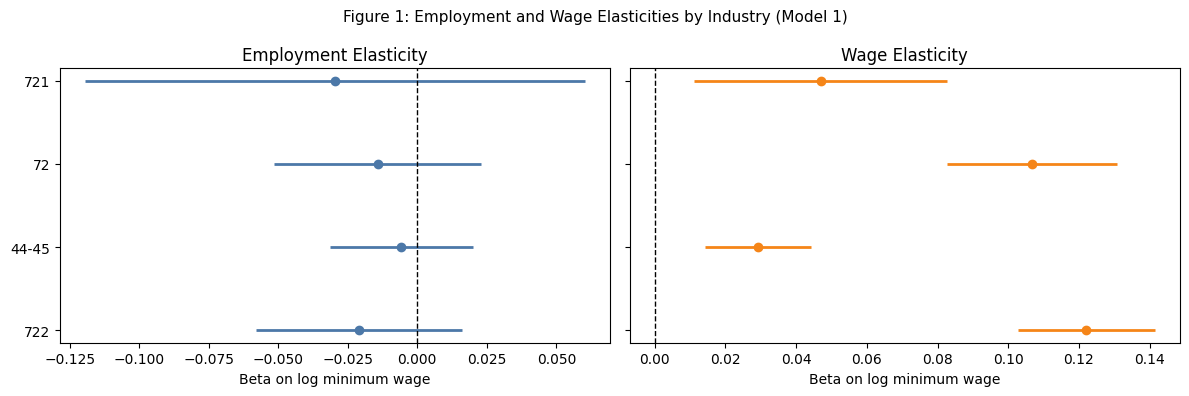

Figure 1 saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
plot_df = industry_results.copy()
plot_df["emp_lo"] = plot_df["emp_beta"] - 1.96 * plot_df["emp_se"]
plot_df["emp_hi"] = plot_df["emp_beta"] + 1.96 * plot_df["emp_se"]
plot_df["wage_lo"] = plot_df["wage_beta"] - 1.96 * plot_df["wage_se"]
plot_df["wage_hi"] = plot_df["wage_beta"] + 1.96 * plot_df["wage_se"]

y = np.arange(len(plot_df))

axes[0].hlines(y, plot_df["emp_lo"], plot_df["emp_hi"], color="#4C78A8", lw=2)
axes[0].plot(plot_df["emp_beta"], y, "o", color="#4C78A8")
axes[0].axvline(0, color="black", ls="--", lw=1)
axes[0].set_title("Employment Elasticity")
axes[0].set_xlabel("Beta on log minimum wage")
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_df["industry_code"])

axes[1].hlines(y, plot_df["wage_lo"], plot_df["wage_hi"], color="#F58518", lw=2)
axes[1].plot(plot_df["wage_beta"], y, "o", color="#F58518")
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set_title("Wage Elasticity")
axes[1].set_xlabel("Beta on log minimum wage")
axes[1].set_yticks(y)
axes[1].set_yticklabels(plot_df["industry_code"])

plt.suptitle(
    "Figure 1: Employment and Wage Elasticities by Industry (Model 1)", fontsize=11
)
plt.tight_layout()
plt.savefig(FIGURES / "fig1_industry_elasticities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

**How to read Figure 1:** Wage elasticities are clearly positive across all four industry definitions, with the strongest pass-through in `722` and `72`. Employment elasticities, by contrast, stay close to zero and have much wider uncertainty bands. This is why the current evidence is strongest on wage pass-through and more cautious on employment loss.


## 5. Robustness Checks for Model 1

The NAICS 722 headline estimate is tested across four alternative specifications:
- Changing the clustering level from `pair_id` to `area_fips`
- Using county FE + year FE instead of county FE + pair-year FE
- Dropping 2020 to remove pandemic-year distortions
- Restricting to complete pair-years where both counties in a pair are observed

Results that remain stable across these checks confirm the estimate is not 
driven by a single modeling choice.


In [9]:
model1_cluster_sensitivity = []
for outcome, outcome_label in [("log_emp", "Employment"), ("log_wage", "Wage")]:
    for cluster_col, cluster_label in [
        ("pair_id", "pair_id"),
        ("area_fips", "area_fips"),
    ]:
        result = absorbed_ols(
            main_722,
            y_col=outcome,
            x_col="log_min_wage",
            fe_cols=["area_fips", "pair_year"],
            cluster_col=cluster_col,
        )
        model1_cluster_sensitivity.append(
            {
                "outcome": outcome_label,
                "cluster": cluster_label,
                "beta": result["beta"],
                "se": result["se"],
                "t_stat": result["t_stat"],
                "p_value": result["p_value"],
                "clusters": result["n_clusters"],
            }
        )

model1_cluster_sensitivity = pd.DataFrame(model1_cluster_sensitivity)
for col in ["beta", "se", "t_stat", "p_value"]:
    model1_cluster_sensitivity[col] = model1_cluster_sensitivity[col].round(4)

model1_cluster_sensitivity

,outcome,cluster,beta,se,t_stat,p_value,clusters
0,Employment,pair_id,-0.0210,0.0189,-1.1071,0.2683,1131
1,Employment,area_fips,-0.0210,0.0170,-1.2306,0.2185,1006
2,Wage,pair_id,0.1221,0.0099,12.2956,0.0000,1131
3,Wage,area_fips,0.1221,0.0091,13.3428,0.0000,1006


In [10]:
model1_spec_checks = []
for spec_label, sample, fe_cols, cluster_col in [
    ("county FE + year FE", main_722, ["area_fips", "year"], "area_fips"),
    ("preferred FE", main_722, ["area_fips", "pair_year"], "pair_id"),
    (
        "preferred FE, drop 2020",
        main_722.loc[main_722["year"] != 2020].copy(),
        ["area_fips", "pair_year"],
        "pair_id",
    ),
    (
        "preferred FE, complete pair-years",
        main_722.loc[main_722["complete_pair_year"]].copy(),
        ["area_fips", "pair_year"],
        "pair_id",
    ),
]:
    result = absorbed_ols(
        sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=fe_cols,
        cluster_col=cluster_col,
    )
    model1_spec_checks.append(
        {
            "spec": spec_label,
            "beta": result["beta"],
            "se": result["se"],
            "t_stat": result["t_stat"],
            "p_value": result["p_value"],
            "n_obs": result["n_obs"],
            "clusters": result["n_clusters"],
        }
    )

model1_spec_checks = pd.DataFrame(model1_spec_checks)
for col in ["beta", "se", "t_stat", "p_value"]:
    model1_spec_checks[col] = model1_spec_checks[col].round(4)

model1_spec_checks

,spec,beta,se,t_stat,p_value,n_obs,clusters
0,county FE + year FE,-0.0739,0.0220,-3.3507,0.0008,39523,1006
1,preferred FE,-0.0210,0.0189,-1.1071,0.2683,39523,1131
2,"preferred FE, drop 2020",-0.0165,0.0190,-0.8679,0.3855,37624,1131
3,"preferred FE, complete pair-years",-0.0210,0.0189,-1.1092,0.2673,33604,1064


**How to read the robustness table:** The NAICS 722 employment coefficient remains 
negative across all four specifications. The preferred FE estimate (β = −0.021, 
p = 0.268) is stable whether 2020 is dropped (β = −0.017) or the sample is 
restricted to complete pair-years (β = −0.021). 

The county FE + year FE specification produces a larger and statistically 
significant estimate (β = −0.074, p = 0.001), but this reflects the weaker 
identification that comes from using national year fixed effects instead of 
pair-year fixed effects. The preferred specification is more conservative and 
more credible.

Overall the headline result is not driven by any single year or sample filter.

## 6. Continuous Treatment Robustness: Signed Minimum-Wage Gap

We also check whether the main result depends on treating the minimum wage as a log-level policy variable. This robustness check replaces `log_min_wage` with `mw_gap`, the signed dollar difference between a county's minimum wage and its paired border county's minimum wage in the same year. The specification keeps the preferred county fixed effects and pair-by-year fixed effects, so identification still comes from within-border-pair-year comparisons.

In [11]:
continuous_gap_results = []
continuous_gap_sample = main_722.dropna(
    subset=["mw_gap", "log_emp", "log_wage", "area_fips", "pair_year", "pair_id"]
).copy()

for outcome, outcome_label in [
    ("log_emp", "Employment"),
    ("log_wage", "Average weekly wage"),
]:
    result = absorbed_ols(
        continuous_gap_sample,
        y_col=outcome,
        x_col="mw_gap",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    continuous_gap_results.append(
        {
            "outcome": outcome_label,
            "treatment": "Signed dollar minimum-wage gap",
            "beta": result["beta"],
            "se": result["se"],
            "t_stat": result["t_stat"],
            "p_value": result["p_value"],
            "n_obs": result["n_obs"],
            "clusters": result["n_clusters"],
        }
    )

continuous_gap_results = pd.DataFrame(continuous_gap_results)
continuous_gap_display = continuous_gap_results.copy()
for col in ["beta", "se", "t_stat", "p_value"]:
    continuous_gap_display[col] = continuous_gap_display[col].round(4)

continuous_gap_display

,outcome,treatment,beta,se,t_stat,p_value,n_obs,clusters
0,Employment,Signed dollar minimum-wage gap,-0.0009,0.0011,-0.811,0.4174,39320,1131
1,Average weekly wage,Signed dollar minimum-wage gap,0.0077,0.0006,13.792,0.0000,39320,1131


**How to read the signed-gap check:** Treatment is measured as county minimum wage minus paired county minimum wage. A $1 larger minimum wage than the paired county is associated with a very small and statistically insignificant employment difference (β = -0.0009, SE = 0.0011, p = 0.417), while the wage effect is positive and precisely estimated (β = 0.0077, SE = 0.0006, p < 0.001). This supports the main finding that larger minimum-wage gaps raise wages without producing broad employment losses.

## 7. Model 2: Illustrative Border Sample

Four state borders are selected for visual and descriptive support:
- `NJ - PA`
- `MN - WI`
- `NY - PA`
- `CA - NV`

These borders were chosen for their clear and sustained minimum wage divergence, 
strong data completeness in NAICS 722, and geographic spread across the country. 
They complement the nationwide estimate by making the border-county comparison 
concrete and easy to visualize.

Estimates from this sample should be treated as descriptive support only. 
The smaller number of pairs produces wider confidence intervals and is not 



In [12]:
model2_emp_722 = absorbed_ols(
    illustrative_722,
    y_col="log_emp",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model2_wage_722 = absorbed_ols(
    illustrative_722,
    y_col="log_wage",
    x_col="log_min_wage",
    fe_cols=["area_fips", "pair_year"],
    cluster_col="pair_id",
)

model2_results = pd.DataFrame(
    [
        tidy_result("M2 722 employment", model2_emp_722),
        tidy_result("M2 722 wages", model2_wage_722),
    ]
)

for col in ["beta", "cluster_se", "t_stat", "p_value", "within_r2"]:
    model2_results[col] = model2_results[col].round(4)

model2_results

,model,beta,cluster_se,t_stat,p_value,within_r2,n_obs,n_clusters
0,M2 722 employment,-0.0216,0.0329,-0.6553,0.5122,0.0014,2790,70
1,M2 722 wages,0.1794,0.0218,8.2217,0.0000,0.2172,2790,70


In [13]:
by_border_results = []
for border in SELECTED_BORDERS:
    border_sample = illustrative_722.loc[illustrative_722["border"] == border].copy()
    border_emp = absorbed_ols(
        border_sample,
        y_col="log_emp",
        x_col="log_min_wage",
        fe_cols=["area_fips", "pair_year"],
        cluster_col="pair_id",
    )
    by_border_results.append(
        {
            "border": border,
            "pair_ids": border_sample["pair_id"].nunique(),
            "n_rows": len(border_sample),
            "emp_beta": border_emp["beta"],
            "emp_se": border_emp["se"],
        }
    )

by_border_results = pd.DataFrame(by_border_results)
for col in ["emp_beta", "emp_se"]:
    by_border_results[col] = by_border_results[col].round(4)

by_border_results

,border,pair_ids,n_rows,emp_beta,emp_se
0,NJ - PA,12,504,-0.1082,0.0393
1,MN - WI,23,891,-0.0023,0.0658
2,NY - PA,18,744,-0.0191,0.0537
3,CA - NV,17,651,0.1317,0.1606


Absorbing FEs for illustrative event study...


Done.
 rel_time    beta     se
        0  0.0000 0.0000
        1 -0.0081 0.0148
        2 -0.0155 0.0179
        3  0.0101 0.0244
        4 -0.0196 0.0105


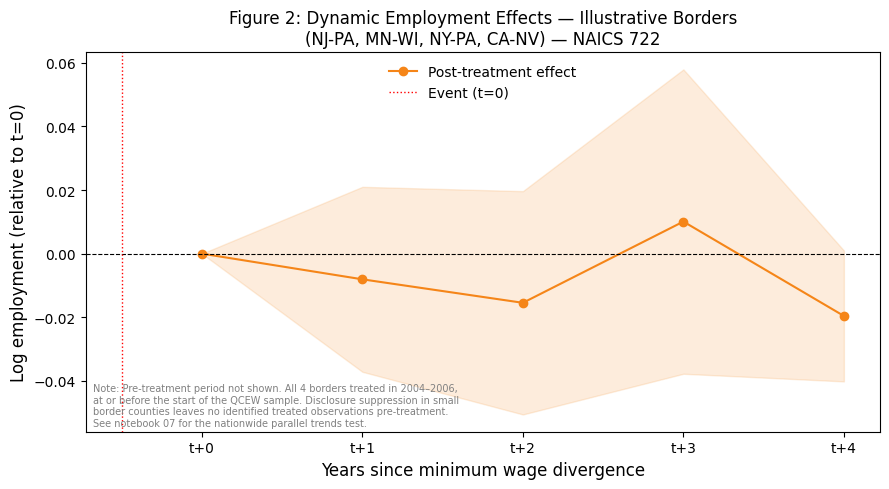

Figure 2 saved.


In [14]:
# ------------------------------------------------------------------
# Changes 14 + 17: Figure 2 redone as event study
#   - x-axis: time-since-adoption (rel_time), t=0 onward
#   - uncertainty bands from clustered SEs
#   - scoped to the 4 illustrative borders only
#
# Why no pre-period:
# All 4 illustrative borders (NJ-PA, MN-WI, NY-PA, CA-NV) have
# event years in 2004-2006, which is at or near the start of the
# QCEW sample (2004). Additionally, QCEW disclosure suppression
# means that treated-side counties in small border pairs are
# missing in early years, leaving zero treated observations at
# rel_time < 0. The pre-period is therefore unidentified for
# these specific borders.
#
# The formal parallel trends test is conducted on the full
# nationwide sample in notebook 07, where pairs with later
# event years provide genuine pre-treatment variation.
# ------------------------------------------------------------------

ILLUS_POST_PERIODS = 4

# --- 1. Build event year per pair ---
df_illus = illustrative_722[illustrative_722["complete_pair_year"] == True].copy()
df_illus["mw_gap"] = df_illus["min_wage"] - df_illus["partner_min_wage"]

pair_gap = (
    df_illus.groupby(["pair_id", "year"])["mw_gap"]
    .apply(lambda x: x.abs().max())
    .reset_index()
    .rename(columns={"mw_gap": "abs_gap"})
)
event_yrs = (
    pair_gap[pair_gap["abs_gap"] > 0]
    .groupby("pair_id")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "event_year"})
)
df_illus = df_illus.merge(event_yrs, on="pair_id", how="inner")
df_illus["rel_time"] = df_illus["year"] - df_illus["event_year"]

# Restrict to post-treatment only (rel_time >= 0)
df_illus_post = df_illus[df_illus["rel_time"] >= 0].copy()
df_illus_post["rel_time_binned"] = df_illus_post["rel_time"].clip(0, ILLUS_POST_PERIODS)

# --- 2. Build event-study dummies, t=0 omitted base ---
rel_times_post = list(range(1, ILLUS_POST_PERIODS + 1))
for t in rel_times_post:
    df_illus_post["D_" + str(t)] = (
        (df_illus_post["treated"] == 1) & (df_illus_post["rel_time_binned"] == t)
    ).astype(float)
dummy_cols_illus = ["D_" + str(t) for t in rel_times_post]


# --- 3. Absorb FEs: county + pair + year ---
def demean_illus(frame, value_cols, fe_cols, max_iter=300, tol=1e-10):
    resid = frame[value_cols].astype(float).copy()
    for _ in range(max_iter):
        prev = resid.to_numpy(copy=True)
        for fe in fe_cols:
            resid = resid - resid.groupby(frame[fe]).transform("mean")
        if np.max(np.abs(resid.to_numpy() - prev)) < tol:
            break
    return resid


print("Absorbing FEs for illustrative event study...")
resid_illus = demean_illus(
    df_illus_post,
    ["log_emp"] + dummy_cols_illus,
    ["area_fips", "pair_id", "year"],
)
print("Done.")

fit_illus = sm.OLS(resid_illus["log_emp"], resid_illus[dummy_cols_illus]).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_illus_post["pair_id"]},
)

# --- 4. Results table (insert t=0 as base, beta=0) ---
res_illus = pd.DataFrame(
    {
        "rel_time": rel_times_post,
        "beta": fit_illus.params[dummy_cols_illus].values,
        "se": fit_illus.bse[dummy_cols_illus].values,
    }
)
res_illus = (
    pd.concat(
        [res_illus, pd.DataFrame({"rel_time": [0], "beta": [0.0], "se": [0.0]})],
        ignore_index=True,
    )
    .sort_values("rel_time")
    .reset_index(drop=True)
)
res_illus["ci_lo"] = res_illus["beta"] - 1.96 * res_illus["se"]
res_illus["ci_hi"] = res_illus["beta"] + 1.96 * res_illus["se"]

print(res_illus[["rel_time", "beta", "se"]].round(4).to_string(index=False))

# --- 5. Plot ---
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.fill_between(
    res_illus["rel_time"],
    res_illus["ci_lo"],
    res_illus["ci_hi"],
    alpha=0.15,
    color="#F58518",
)
ax2.plot(
    res_illus["rel_time"],
    res_illus["beta"],
    marker="o",
    color="#F58518",
    label="Post-treatment effect",
)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axvline(-0.5, color="red", linewidth=1, linestyle=":", label="Event (t=0)")
ax2.set_xlabel("Years since minimum wage divergence", fontsize=12)
ax2.set_ylabel("Log employment (relative to t=0)", fontsize=12)
ax2.set_title(
    "Figure 2: Dynamic Employment Effects — Illustrative Borders\n"
    "(NJ-PA, MN-WI, NY-PA, CA-NV) — NAICS 722",
    fontsize=12,
)
ax2.set_xticks(res_illus["rel_time"])
ax2.set_xticklabels(["t+" + str(t) for t in res_illus["rel_time"]])
ax2.legend(frameon=False)
ax2.annotate(
    "Note: Pre-treatment period not shown. All 4 borders treated in 2004–2006,\n"
    "at or before the start of the QCEW sample. Disclosure suppression in small\n"
    "border counties leaves no identified treated observations pre-treatment.\n"
    "See notebook 07 for the nationwide parallel trends test.",
    xy=(0.01, 0.01),
    xycoords="axes fraction",
    fontsize=7,
    color="gray",
    va="bottom",
)
plt.tight_layout()
plt.savefig(FIGURES / "fig2_event_study_illustrative.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

**How to read Figure 2:** This plot shows the dynamic employment effect in the four illustrative borders (NJ-PA, MN-WI, NY-PA, CA-NV) in the years following minimum wage divergence. The pre-treatment period is omitted because all four borders experienced their first minimum wage divergence in 2004-2006, at or near the start of the QCEW sample. Additionally, QCEW disclosure suppression in small border counties leaves no identified treated-side observations in the pre-period. The formal parallel trends test using the full nationwide sample is presented in notebook 08. Post-treatment coefficients are small and statistically imprecise, consistent with the nationwide finding of no large employment losses in food services.